In [15]:
"""
HiGAN+ Batch Inference Script
==============================
Processes all images from input folder and generates handwriting samples
using extracted styles with custom text prompts.
"""

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path
from tqdm import tqdm
import sys
import os
import random

# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths
PROJECT_PATH = Path(r"B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch")
INPUT_DIR = PROJECT_PATH / "inference" / "input"
OUTPUT_DIR = PROJECT_PATH / "inference" / "output"
CHECKPOINT_PATH = PROJECT_PATH / "server_files" / "epoch_70.pth"
WORD_LIST_PATH = PROJECT_PATH / "data" / "english_words.txt"
PRETRAINED_WID_PATH = PROJECT_PATH / "pretrained" / "wid_iam_new.pth"

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Image processing parameters
IMG_HEIGHT = 64  # Standard height for IAM dataset
CHAR_WIDTH = 32  # Character width used in training

# Number of random words to generate per image
NUM_RANDOM_WORDS = 6

# ============================================================================
# LOAD PROJECT DEPENDENCIES
# ============================================================================

# Add project path to sys.path
os.chdir(PROJECT_PATH)
if str(PROJECT_PATH) not in sys.path:
    sys.path.insert(0, str(PROJECT_PATH))

# Import project modules
try:
    from lib.utils import yaml2config
    from lib.alphabet import strLabelConverter, get_true_alphabet
    from networks.BigGAN_networks import Generator
    from networks.module import StyleEncoder, StyleBackbone
    
    print("✓ Project modules loaded successfully")
except ImportError as e:
    print(f"⚠ Error importing project modules: {e}")
    print("Make sure the project structure is correct and all modules are available")
    sys.exit(1)

# ============================================================================
# LOAD CONFIGURATION
# ============================================================================

config_path = PROJECT_PATH / 'configs' / 'gan_iam.yml'
cfg = yaml2config(str(config_path))
cfg.device = str(DEVICE)

print(f"✓ Configuration loaded from {config_path}")

# ============================================================================
# LOAD WORD LIST
# ============================================================================

def load_word_list(path):
    """Load word list for random word generation."""
    words = []
    with open(path, 'r') as f:
        for line in f:
            word = line.strip()
            if word and len(word) <= 15:  # Filter reasonable length words
                words.append(word)
    return words

word_list = load_word_list(WORD_LIST_PATH)
print(f"✓ Loaded {len(word_list)} words from corpus")

def get_random_words(n=NUM_RANDOM_WORDS):
    """Get n random words from the word list."""
    return random.sample(word_list, min(n, len(word_list)))

# ============================================================================
# INITIALIZE LABEL CONVERTER
# ============================================================================

# Get the alphabet key from dataset name
alphabet_key = '_'.join(cfg.dataset.split('_')[:2])
label_converter = strLabelConverter(alphabet_key)
alphabet = label_converter.alphabet
print(f"✓ Label converter initialized (alphabet size: {len(alphabet)})")

# ============================================================================
# INITIALIZE MODELS
# ============================================================================

print("\nInitializing models...")

# Generator
generator = Generator(**cfg.GenModel).to(DEVICE)
print(f"✓ Generator initialized (style_dim: {cfg.GenModel.style_dim})")

# Style Encoder and Backbone
style_backbone = StyleBackbone(**cfg.StyBackbone).to(DEVICE)
style_encoder = StyleEncoder(**cfg.EncModel).to(DEVICE)
print(f"✓ Style encoder initialized")

# ============================================================================
# LOAD CHECKPOINT AND PRETRAINED MODELS
# ============================================================================

print(f"\nLoading checkpoint from: {CHECKPOINT_PATH}")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

# Load generator and style encoder from training checkpoint
generator.load_state_dict(checkpoint['generator'])
style_encoder.load_state_dict(checkpoint['style_encoder'])
print(f"✓ Loaded generator and style_encoder from checkpoint (epoch {checkpoint.get('epoch', 'N/A')})")

# IMPORTANT: StyleBackbone is NOT in the training checkpoint!
# It must be loaded from the pretrained Writer ID model
if PRETRAINED_WID_PATH.exists():
    wid_dict = torch.load(PRETRAINED_WID_PATH, map_location=DEVICE)
    if 'StyleBackbone' in wid_dict:
        style_backbone.load_state_dict(wid_dict['StyleBackbone'])
        print(f"✓ Loaded StyleBackbone from pretrained WID model")
    else:
        print("⚠ StyleBackbone not found in pretrained WID model")
else:
    print(f"⚠ Pretrained WID not found at {PRETRAINED_WID_PATH}")

# Set models to eval mode
generator.eval()
style_encoder.eval()
style_backbone.eval()

print("✓ All models loaded and set to evaluation mode")

# ============================================================================
# IMAGE PREPROCESSING FUNCTIONS (MATCHING TRAINING PIPELINE)
# ============================================================================

def recalc_len(length, scale=CHAR_WIDTH):
    """Recalculate length to be divisible by char_width (matching training)."""
    tmp = length % scale
    return length + scale - tmp if tmp != 0 else length

def load_and_preprocess_image(image_path, target_height=IMG_HEIGHT):
    """
    Load and preprocess an image for style extraction.
    MATCHES the training data preprocessing pipeline exactly.
    
    Args:
        image_path: Path to input image
        target_height: Target height for resizing (64 for IAM)
    
    Returns:
        Preprocessed tensor in range [-1, 1] and image width
    """
    # Load image as grayscale
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    h, w = img.shape[:2]
    
    # Resize to target height while maintaining aspect ratio
    r = target_height / float(h)
    new_w = int(w * r)
    
    # Ensure minimum width
    new_w = max(new_w, CHAR_WIDTH * 2)
    
    # Make width divisible by CHAR_WIDTH (matching training)
    new_w = recalc_len(new_w, CHAR_WIDTH)
    
    dim = (new_w, target_height)
    
    if new_w < w:
        img = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
    else:
        img = cv2.resize(img, dim, interpolation=cv2.INTER_LINEAR)
    
    # CRITICAL: Training data format is white text on black background
    # The dataset uses: res_img = 255 - resize_img (inverts the image)
    # Then normalizes with: (x / 255 - 0.5) / 0.5 = (x - 127.5) / 127.5
    # Result: black bg -> -1, white text -> +1
    
    # Check if image has light background (dark text on light bg)
    if img.mean() > 127:
        # Light background -> invert to get white text on black background
        img = 255 - img
    
    # Convert to float and normalize to [-1, 1]
    # ToTensor: [0, 255] -> [0, 1]
    # Normalize([0.5], [0.5]): (x - 0.5) / 0.5 -> [-1, 1]
    img_float = img.astype(np.float32) / 255.0  # [0, 1]
    img_normalized = (img_float - 0.5) / 0.5    # [-1, 1]
    
    # Convert to tensor [1, 1, H, W]
    img_tensor = torch.from_numpy(img_normalized).unsqueeze(0).unsqueeze(0).float()
    
    return img_tensor, new_w

def tensor_to_image(tensor):
    """
    Convert output tensor to displayable numpy image.
    
    Args:
        tensor: Tensor of shape [1, H, W] or [H, W] in range [-1, 1]
    
    Returns:
        Numpy array in uint8 format (white background, dark text)
    """
    if tensor.dim() == 3:
        tensor = tensor.squeeze(0)
    
    img_np = tensor.cpu().numpy()
    
    # Denormalize from [-1, 1] to [0, 1]
    img_np = (img_np + 1) / 2.0
    
    # Invert for display (white background, black text)
    img_np = 1.0 - img_np
    
    # Clip and convert to uint8
    img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
    
    return img_np

# ============================================================================
# INFERENCE FUNCTION
# ============================================================================

@torch.no_grad()
def run_inference(input_dir, output_dir, num_words=NUM_RANDOM_WORDS):
    """
    Run inference on all images in input directory.
    
    Args:
        input_dir: Path to input directory containing style reference images
        output_dir: Path to output directory for generated images
        num_words: Number of random words to generate per image
    """
    # Get all image files
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif'}
    image_files = [
        f for f in input_dir.iterdir() 
        if f.suffix.lower() in image_extensions
    ]
    
    if not image_files:
        print(f"⚠ No images found in {input_dir}")
        return
    
    print(f"\nFound {len(image_files)} images to process")
    print(f"Generating {num_words} random words per image")
    print("-" * 60)
    
    # Process each image
    for img_idx, img_path in enumerate(tqdm(image_files, desc="Processing images")):
        try:
            # Load and preprocess image (matching training pipeline)
            img_tensor, img_width = load_and_preprocess_image(img_path)
            img_tensor = img_tensor.to(DEVICE)
            
            # Create image length tensor
            img_len = torch.tensor([img_width], dtype=torch.long).to(DEVICE)
            
            # Extract style from reference image
            style_vector = style_encoder(img_tensor, img_len, style_backbone, vae_mode=False)
            
            # Debug: print style vector stats for first image
            if img_idx == 0:
                print(f"\nStyle vector for {img_path.name}:")
                print(f"  Shape: {style_vector.shape}")
                print(f"  Mean: {style_vector.mean().item():.4f}")
                print(f"  Std: {style_vector.std().item():.4f}")
                print(f"  Min: {style_vector.min().item():.4f}")
                print(f"  Max: {style_vector.max().item():.4f}")
            
            # Get random words for this image
            random_words = get_random_words(num_words)
            
            # Encode all words
            custom_lbs, custom_lb_lens = label_converter.encode(random_words)
            custom_lbs = custom_lbs.to(DEVICE)
            custom_lb_lens = custom_lb_lens.to(DEVICE)
            
            # Generate images with random words
            generated_images = []
            
            for text_idx, text in enumerate(random_words):
                # Get label and length for this text
                text_lb = custom_lbs[text_idx:text_idx+1]
                text_lb_len = custom_lb_lens[text_idx:text_idx+1]
                
                # Generate image using the extracted style
                fake_img = generator(style_vector, text_lb, text_lb_len)
                generated_images.append(fake_img)
            
            # Stack all generated images
            generated_images = torch.cat(generated_images, dim=0)
            
            # Create visualization grid
            n_texts = len(random_words)
            fig, axes = plt.subplots(n_texts + 1, 1, figsize=(14, 2 * (n_texts + 1)))
            
            # Plot reference image
            ref_img = tensor_to_image(img_tensor.squeeze())
            axes[0].imshow(ref_img, cmap='gray')
            axes[0].set_title(f'Reference Image: {img_path.name}', 
                            fontsize=12, fontweight='bold')
            axes[0].axis('off')
            
            # Plot generated images
            for i, text in enumerate(random_words):
                gen_img = tensor_to_image(generated_images[i])
                axes[i + 1].imshow(gen_img, cmap='gray')
                axes[i + 1].set_title(f'Generated: "{text}"', fontsize=11)
                axes[i + 1].axis('off')
            
            plt.tight_layout()
            
            # Save combined visualization only
            output_path = output_dir / f"{img_path.stem}_combined.png"
            plt.savefig(output_path, dpi=150, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            plt.close()
            
            print(f"✓ Processed {img_path.name} -> {output_path.name}")
            
        except Exception as e:
            print(f"✗ Error processing {img_path.name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print("-" * 60)
    print(f"✓ Inference complete! Results saved to {output_dir}")
    print(f"  - {len(image_files)} combined visualizations generated")

Using device: cuda
✓ Project modules loaded successfully
✓ Configuration loaded from B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch\configs\gan_iam.yml
✓ Loaded 451467 words from corpus
✓ Label converter initialized (alphabet size: 80)

Initializing models...
✓ Generator initialized (style_dim: 32)
✓ Style encoder initialized

Loading checkpoint from: B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch\server_files\epoch_70.pth
✓ Loaded generator and style_encoder from checkpoint (epoch 70)
✓ Loaded StyleBackbone from pretrained WID model
✓ All models loaded and set to evaluation mode
✓ Loaded generator and style_encoder from checkpoint (epoch 70)
✓ Loaded StyleBackbone from pretrained WID model
✓ All models loaded and set to evaluation mode


In [16]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*60)
    print("HiGAN+ BATCH INFERENCE")
    print("="*60)
    print(f"Input directory:  {INPUT_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Checkpoint:       {CHECKPOINT_PATH}")
    print(f"Random words per image: {NUM_RANDOM_WORDS}")
    print("="*60)
    
    # Check if input directory exists and has images
    if not INPUT_DIR.exists():
        print(f"\n⚠ Input directory does not exist: {INPUT_DIR}")
        print("Creating directory...")
        INPUT_DIR.mkdir(parents=True, exist_ok=True)
        print(f"✓ Created {INPUT_DIR}")
        print("\nPlease add handwriting images to the input directory and run again.")
    else:
        # Run inference
        run_inference(INPUT_DIR, OUTPUT_DIR, NUM_RANDOM_WORDS)

    print("\n" + "="*60)
    print("INFERENCE PIPELINE COMPLETE")
    print("="*60)

HiGAN+ BATCH INFERENCE
Input directory:  B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch\inference\input
Output directory: B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch\inference\output
Checkpoint:       B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch\server_files\epoch_70.pth
Random words per image: 6

Found 2 images to process
Generating 6 random words per image
------------------------------------------------------------


Processing images:   0%|          | 0/2 [00:00<?, ?it/s]


Style vector for image.png:
  Shape: torch.Size([1, 32])
  Mean: -0.0551
  Std: 0.9819
  Min: -2.3955
  Max: 3.1373


Processing images:  50%|█████     | 1/2 [00:00<00:00,  1.21it/s]

✓ Processed image.png -> image_combined.png


Processing images: 100%|██████████| 2/2 [00:01<00:00,  1.46it/s]

✓ Processed Screenshot 2025-11-26 232829.png -> Screenshot 2025-11-26 232829_combined.png
------------------------------------------------------------
✓ Inference complete! Results saved to B:\College\DL\handwriting_autocomplete_system\Higan+ from Scratch\inference\output
  - 2 combined visualizations generated

INFERENCE PIPELINE COMPLETE


In [17]:
# Debug: Compare style vectors between different input images
print("="*60)
print("STYLE VECTOR COMPARISON")
print("="*60)

image_files = list(INPUT_DIR.iterdir())
image_files = [f for f in image_files if f.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}]

style_vectors = []
for img_path in image_files:
    img_tensor, img_width = load_and_preprocess_image(img_path)
    img_tensor = img_tensor.to(DEVICE)
    img_len = torch.tensor([img_width], dtype=torch.long).to(DEVICE)
    
    with torch.no_grad():
        style_vector = style_encoder(img_tensor, img_len, style_backbone, vae_mode=False)
    
    style_vectors.append(style_vector.cpu())
    print(f"\n{img_path.name}:")
    print(f"  Image shape after preprocessing: {img_tensor.shape}")
    print(f"  Image width: {img_width}")
    print(f"  Style vector: mean={style_vector.mean().item():.4f}, std={style_vector.std().item():.4f}")
    print(f"  First 10 values: {style_vector[0, :10].tolist()}")

# Compare style vectors
if len(style_vectors) >= 2:
    diff = (style_vectors[0] - style_vectors[1]).abs()
    cosine_sim = F.cosine_similarity(style_vectors[0], style_vectors[1]).item()
    print(f"\n--- Comparison ---")
    print(f"L1 Distance: {diff.sum().item():.4f}")
    print(f"Max absolute diff: {diff.max().item():.4f}")
    print(f"Cosine Similarity: {cosine_sim:.4f}")
    print(f"(If cosine sim is ~1.0, styles are nearly identical - that's the bug!)")

STYLE VECTOR COMPARISON

image.png:
  Image shape after preprocessing: torch.Size([1, 1, 64, 224])
  Image width: 224
  Style vector: mean=-0.0551, std=0.9819
  First 10 values: [-2.3955132961273193, 0.45090407133102417, -0.386286199092865, -0.8222348690032959, -0.8839098811149597, 0.4798300564289093, -0.5773907899856567, -0.2463589459657669, -0.45240336656570435, 1.854603886604309]

Screenshot 2025-11-26 232829.png:
  Image shape after preprocessing: torch.Size([1, 1, 64, 128])
  Image width: 128
  Style vector: mean=-0.1384, std=1.0721
  First 10 values: [-0.13615933060646057, 0.5906950831413269, 2.520531177520752, -0.3270772099494934, -0.6442227959632874, -0.314800500869751, 0.284050852060318, -0.7032977938652039, -1.8953059911727905, 0.6764901876449585]

--- Comparison ---
L1 Distance: 31.9812
Max absolute diff: 2.9068
Cosine Similarity: 0.3240
(If cosine sim is ~1.0, styles are nearly identical - that's the bug!)


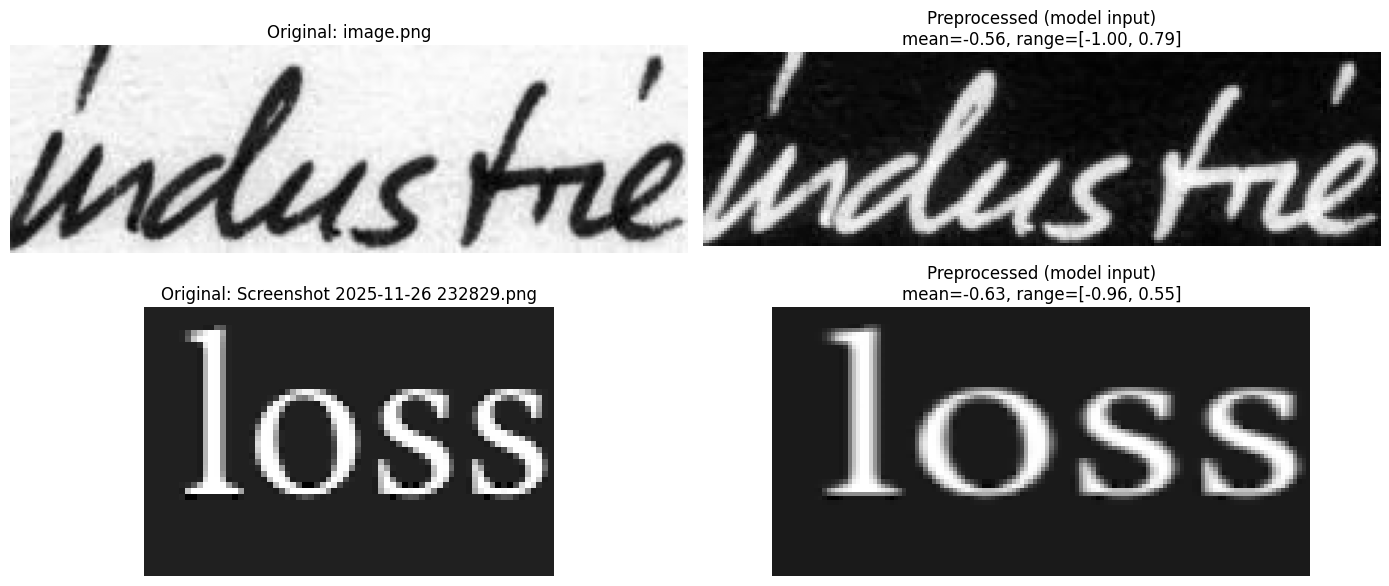

✓ Saved preprocessing debug image


In [18]:
# Visualize the preprocessed images to verify they look correct
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for idx, img_path in enumerate(image_files[:2]):
    img_tensor, img_width = load_and_preprocess_image(img_path)
    
    # Show preprocessed image (as model sees it)
    preprocessed = img_tensor.squeeze().numpy()
    # Convert from [-1, 1] to [0, 1] for display
    preprocessed_display = (preprocessed + 1) / 2
    
    # Show original image
    original = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original: {img_path.name}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(preprocessed_display, cmap='gray')
    axes[idx, 1].set_title(f'Preprocessed (model input)\nmean={preprocessed.mean():.2f}, range=[{preprocessed.min():.2f}, {preprocessed.max():.2f}]')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'debug_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved preprocessing debug image")

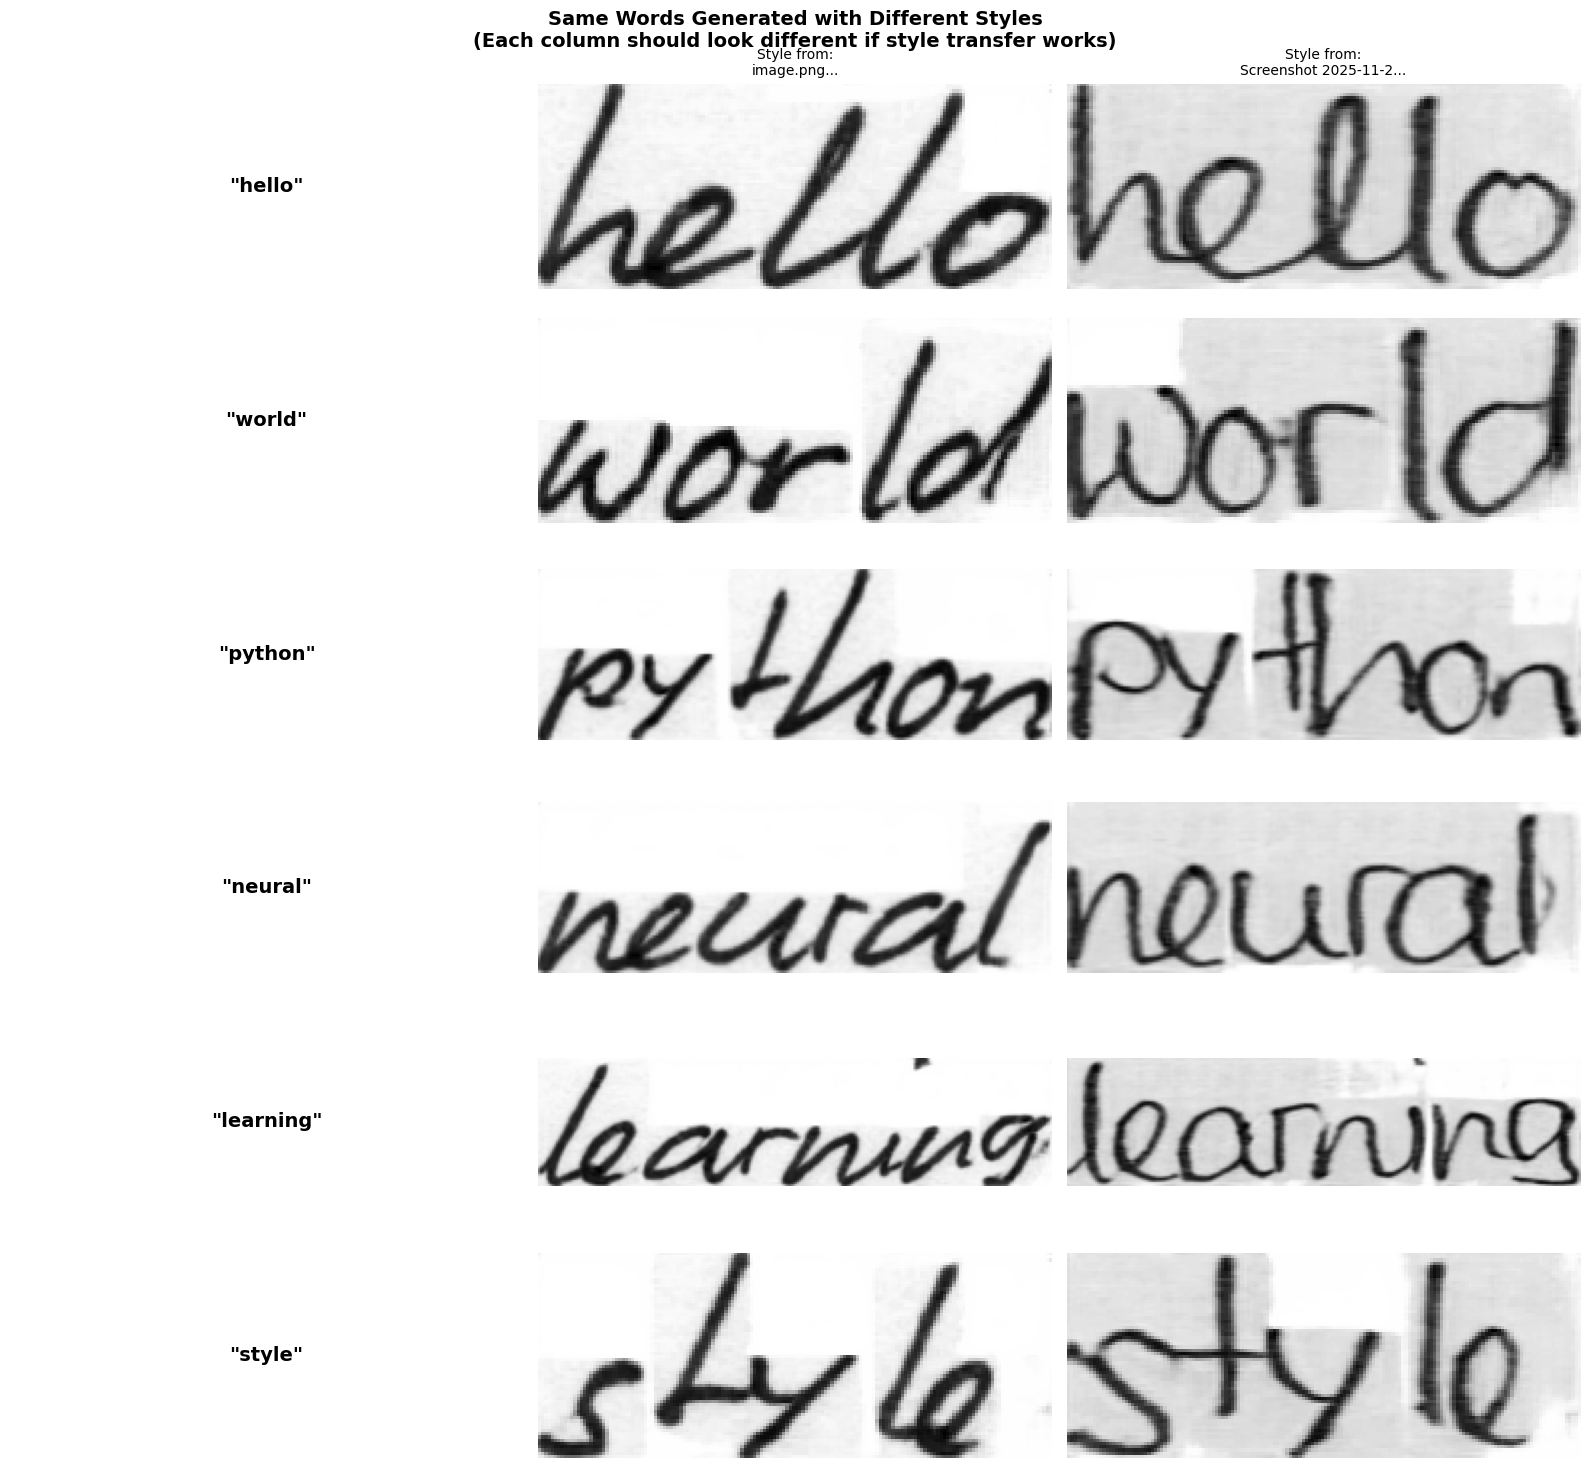

✓ Saved style comparison image


In [19]:
# Generate SAME words with DIFFERENT styles for direct comparison
test_words = ["hello", "world", "python", "neural", "learning", "style"]

fig, axes = plt.subplots(len(test_words), len(image_files) + 1, figsize=(16, 2.5 * len(test_words)))

# First column: word labels
for i, word in enumerate(test_words):
    axes[i, 0].text(0.5, 0.5, f'"{word}"', fontsize=14, fontweight='bold',
                    ha='center', va='center')
    axes[i, 0].axis('off')

# Generate for each style
for style_idx, img_path in enumerate(image_files):
    img_tensor, img_width = load_and_preprocess_image(img_path)
    img_tensor = img_tensor.to(DEVICE)
    img_len = torch.tensor([img_width], dtype=torch.long).to(DEVICE)
    
    with torch.no_grad():
        style_vector = style_encoder(img_tensor, img_len, style_backbone, vae_mode=False)
        
        for word_idx, word in enumerate(test_words):
            # Encode the word
            lbs, lb_lens = label_converter.encode([word])
            lbs = lbs.to(DEVICE)
            lb_lens = lb_lens.to(DEVICE)
            
            # Generate
            fake_img = generator(style_vector, lbs, lb_lens)
            
            # Convert to displayable image
            gen_img = tensor_to_image(fake_img.squeeze())
            
            axes[word_idx, style_idx + 1].imshow(gen_img, cmap='gray')
            if word_idx == 0:
                axes[word_idx, style_idx + 1].set_title(f'Style from:\n{img_path.name[:20]}...', fontsize=10)
            axes[word_idx, style_idx + 1].axis('off')

plt.suptitle('Same Words Generated with Different Styles\n(Each column should look different if style transfer works)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'style_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved style comparison image")